# Giới thiệu

- Bệnh đái tháo đường (Diabetes Mellitus) là một trong những bệnh mãn tính phổ biến nhất trên toàn cầu, xảy ra khi cơ thể không thể sản xuất đủ insulin hoặc sử dụng insulin một cách hiệu quả.
- Nếu không được phát hiện và điều trị kịp thời, bệnh có thể dẫn đến nhiều biến chứng nguy hiểm như tim mạch, suy thận, mù lòa hoặc tổn thương thần kinh.

- Trong bối cảnh đó, học máy (Machine Learning) đóng vai trò quan trọng trong việc phân tích dữ liệu y tế để dự đoán nguy cơ mắc bệnh sớm, giúp các bác sĩ và tổ chức y tế ra quyết định nhanh hơn và chính xác hơn.

## Bộ dữ liệu được sử dụng trong nghiên cứu này là Pima Indians Diabetes Dataset, chứa các thông tin lâm sàng của phụ nữ gốc Pima (Mỹ) với 8 đặc trưng chính liên quan đến sức khỏe như:

- Pregnancies – số lần mang thai

- Glucose – nồng độ glucose trong máu

- BloodPressure – huyết áp tâm trương

- SkinThickness – độ dày lớp da (mm)

- Insulin – nồng độ insulin huyết thanh

- BMI – chỉ số khối cơ thể

- DiabetesPedigreeFunction – chỉ số di truyền về nguy cơ tiểu đường

- Age – tuổi của bệnh nhân

- Cột Outcome (0 = không bị tiểu đường, 1 = bị tiểu đường) là nhãn mục tiêu.
Mục tiêu của bài toán là xây dựng mô hình dự đoán khả năng mắc bệnh đái tháo đường dựa trên các đặc trưng nêu trên.

Trong dự án này, chúng tôi triển khai và so sánh 3 mô hình học máy:

Logistic Regression – mô hình tuyến tính đơn giản, dễ diễn giải.

Random Forest – mô hình cây rừng ngẫu nhiên có khả năng học phi tuyến.

XGBoost – mô hình boosting mạnh mẽ, tối ưu hiệu suất dự đoán.

Kết quả giúp đánh giá hiệu năng, độ chính xác và khả năng ứng dụng thực tế của từng mô hình trong việc hỗ trợ dự đoán sớm bệnh đái tháo đường.

# *I. Làm sạch dữ liệu***

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/kaggle/input/diabetescsv/diabetes.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [3]:
# Hiển thị 5 dòng đầu
print("\n5 dòng đầu tiên:")
print(df.head())


5 dòng đầu tiên:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


# 1.1 Kiểm tra giá trị thiếu


In [4]:
print("Tổng số giá trị NaN trong mỗi cột:")
print(df.isnull().sum())

Tổng số giá trị NaN trong mỗi cột:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


# 1.2 Kiểm tra giá trị độc nhất

In [5]:
print("Số lượng giá trị độc nhất trong mỗi cột:")
print(df.nunique())

Số lượng giá trị độc nhất trong mỗi cột:
Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64


In [6]:
df['Insulin'] = df['Insulin'].astype('float64')  # Chuyển Insulin sang float64
df['Outcome'] = df['Outcome'].astype('category')  # Chuyển Outcome sang category

# 1.3 Kiểm tra và loại bỏ dữ liệu trùng lặp

In [7]:
# Kiểm tra số lượng dòng trùng lặp
duplicate_rows = df.duplicated().sum()
print(f"Số lượng dòng trùng lặp: {duplicate_rows}")

Số lượng dòng trùng lặp: 0


# 1.4 Xác định và loại bỏ outlier

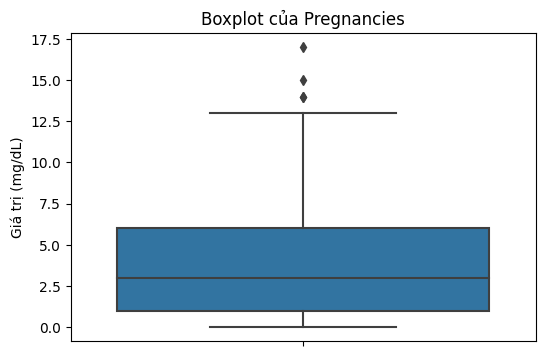

In [8]:
# Boxplot riêng cho từng biến
# 1. Pregnancies
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Pregnancies'])
plt.title("Boxplot của Pregnancies")
plt.ylabel("Giá trị (mg/dL)")
plt.show()

 *1. Pregnancies:
Outlier: Giá trị cao (>13, tối đa 17), nhưng hợp lý trong bối cảnh dân số Pima.
Lý do: Không bất thường, phản ánh đặc điểm sinh sản.*

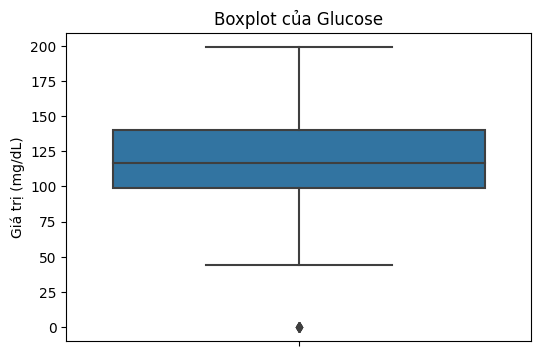

In [9]:
# Boxplot riêng cho từng biến
# 2. Glucose
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Glucose'])
plt.title("Boxplot của Glucose")
plt.ylabel("Giá trị (mg/dL)")
plt.show()

2. Glucose (Nồng độ glucose)

Outlier quan sát: 5 giá trị 0 (dưới râu, ~50 mg/dL).
Lý do không hợp lý: Nồng độ glucose trong máu không thể là 0 ở người sống, ngay cả khi đói (thường ≥70 mg/dL). Đây có thể là missing data hoặc lỗi nhập liệu.

Biện pháp xử lý:

Impute: Thay 0 bằng trung vịcủa cột.

In [10]:
df['Glucose'] = df['Glucose'].replace(0, df['Glucose'].median())

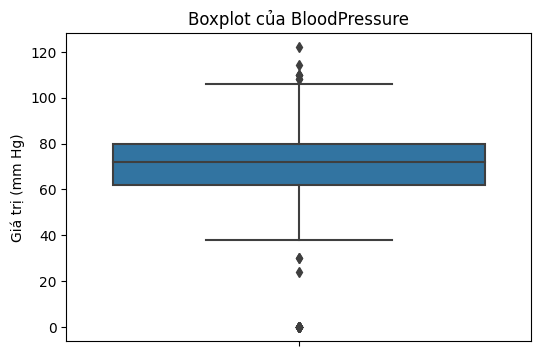

In [11]:
# 3. BloodPressure
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['BloodPressure'])
plt.title("Boxplot của BloodPressure")
plt.ylabel("Giá trị (mm Hg)")
plt.show()

3. BloodPressure (Huyết áp tâm trương)

Outlier quan sát: 35 giá trị 0 (dưới râu, ~30 mm Hg).
Lý do không hợp lý: Huyết áp tâm trương không thể là 0 (giá trị bình thường 60–90 mm Hg). Đây là lỗi đo.
Biện pháp xử lý:

Impute: Thay 0 bằng trung vị (~72 mm Hg).

In [12]:
df['BloodPressure'] = df['BloodPressure'].replace(0, df['BloodPressure'].median())

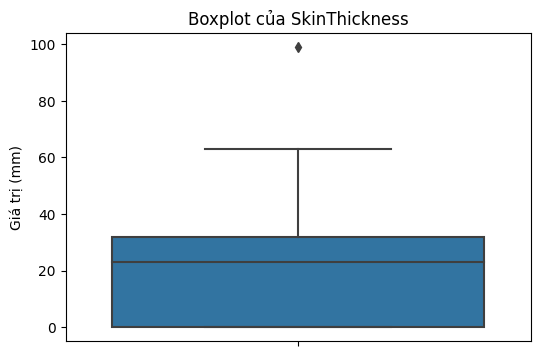

In [13]:
# 4. SkinThickness
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['SkinThickness'])
plt.title("Boxplot của SkinThickness")
plt.ylabel("Giá trị (mm)")
plt.show()

4. SkinThickness (Độ dày nếp da)

Outlier quan sát: 227 giá trị 0 (dưới râu, ~0 mm) và một số giá trị cao (>50 mm).
Lý do không hợp lý: 0 mm là không khả thi (độ dày nếp da tối thiểu ~7 mm ở người trưởng thành), có thể là missing data. Giá trị cao (>50 mm) hiếm nhưng có thể hợp lý ở người béo phì.
Biện pháp xử lý:

Impute: Thay 0 bằng trung vị (~23 mm).

In [14]:
df['SkinThickness'] = df['SkinThickness'].replace(0, df['SkinThickness'].median())

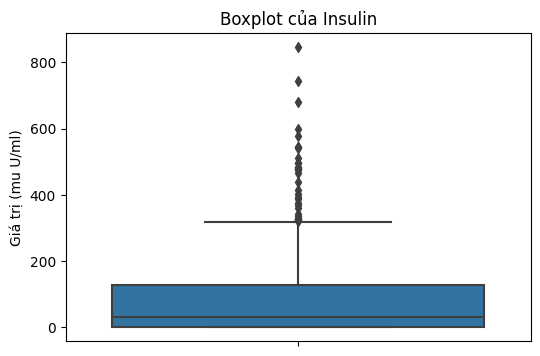

In [15]:
# 5. Insulin
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Insulin'])
plt.title("Boxplot của Insulin")
plt.ylabel("Giá trị (mu U/ml)")
plt.show()

5. Insulin (Mức insulin)

Outlier quan sát: 374 giá trị 0 (dưới râu, ~0 mu U/ml) và nhiều giá trị cao (>300 mu U/ml, lên đến 846).
Lý do không hợp lý: 0 mu U/ml là bất thường (mức insulin bình thường 2–30 mu U/ml khi đói, tăng sau OGTT), có thể là missing data. Giá trị cao (>600) hiếm nhưng có thể do đề kháng insulin cực độ hoặc lỗi đo.
Biện pháp xử lý:

Impute: Thay 0 bằng trung vị (~32 mu U/ml).



In [16]:
df['Insulin'] = df['Insulin'].replace(0, df['Insulin'].median())

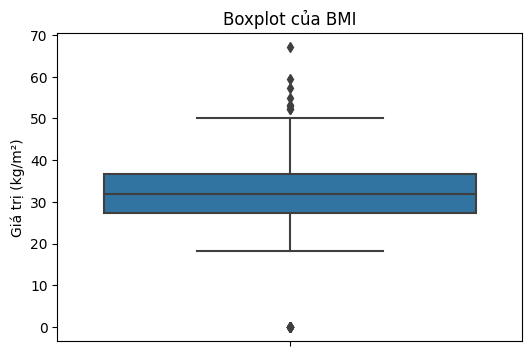

In [17]:
# 6. BMI
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['BMI'])
plt.title("Boxplot của BMI")
plt.ylabel("Giá trị (kg/m²)")
plt.show()

6. BMI (Chỉ số khối cơ thể)

Outlier quan sát: 11 giá trị 0 (dưới râu, ~15 kg/m²) và một số giá trị cao (>50 kg/m², lên đến 67.1).
Lý do không hợp lý: 0 kg/m² là không thể (BMI bình thường 18.5–24.9), có thể là missing data. Giá trị cao (>50) hiếm nhưng khả thi ở người béo phì morbid.
Biện pháp xử lý:

Impute: Thay 0 bằng trung vị (~32.0 kg/m²).


In [18]:
df['BMI'] = df['BMI'].replace(0, df['BMI'].median())

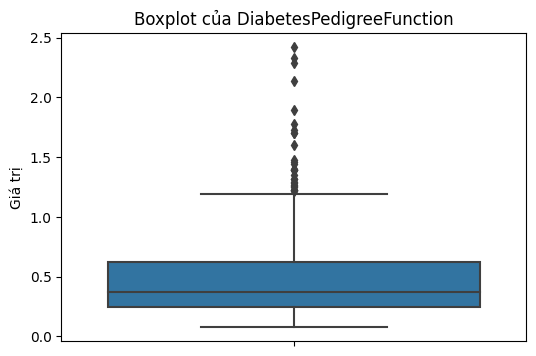

In [19]:
# 7. DiabetesPedigreeFunction
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['DiabetesPedigreeFunction'])
plt.title("Boxplot của DiabetesPedigreeFunction")
plt.ylabel("Giá trị")
plt.show()

7. DiabetesPedigreeFunction (Hàm phả hệ tiểu đường)

Outlier quan sát: Giá trị >1.5 (lên đến 2.42).
Lý do không hợp lý: Không có, vì DPF là giá trị liên tục phản ánh nguy cơ di truyền, và giá trị cao (>1.5) hợp lý ở quần thể Pima có tiền sử tiểu đường cao.
Biện pháp xử lý: Không cần xử lý, nhưng chuẩn hóa (StandardScaler) để giảm tác động outlier trong mô hình.

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['DiabetesPedigreeFunction'] = scaler.fit_transform(df[['DiabetesPedigreeFunction']])



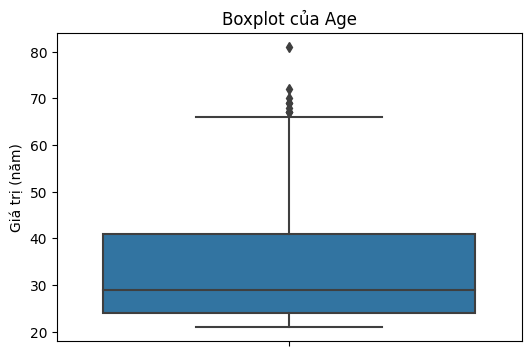

In [21]:
# 8. Age
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Age'])
plt.title("Boxplot của Age")
plt.ylabel("Giá trị (năm)")
plt.show()

8. Age (Tuổi)

Outlier quan sát: Giá trị >60 (lên đến 81).
Lý do không hợp lý: Không có, vì tuổi cao (>60) là yếu tố nguy cơ tự nhiên và hợp lý trong quần thể Pima.
Biện pháp xử lý: Không cần xử lý, giữ nguyên để phản ánh đặc điểm dân số.

# *II. Exploratory Data Analysis (EDA)*

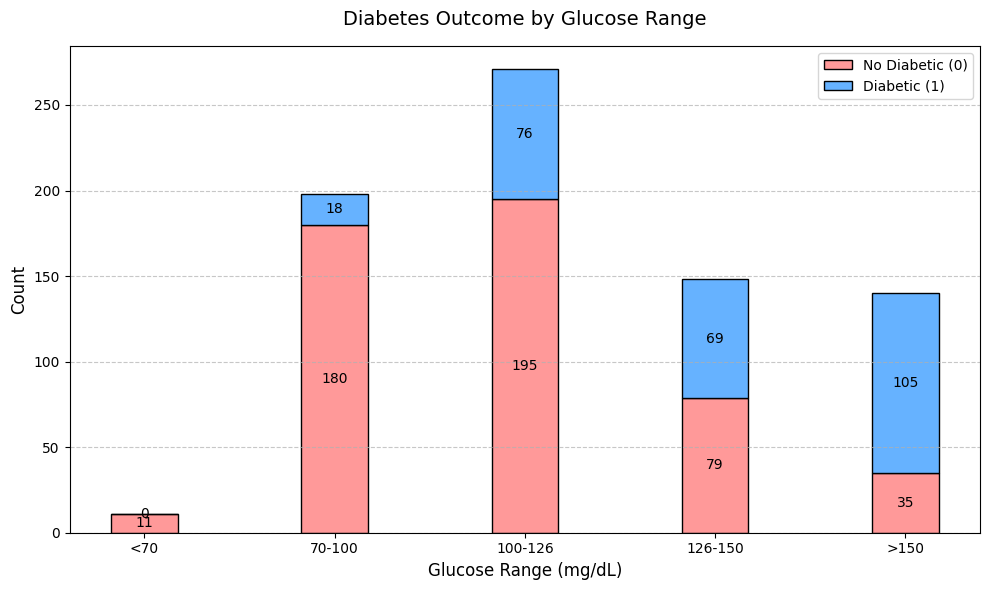

Số lượng Outcome theo khoảng Glucose:
Outcome        0    1
Glucose_Bin          
<70           11    0
70-100       180   18
100-126      195   76
126-150       79   69
>150          35  105


In [22]:
# Chia Glucose thành các khoảng
bins = [0, 70, 100, 126, 150, 200]
labels = ['<70', '70-100', '100-126', '126-150', '>150']
df['Glucose_Bin'] = pd.cut(df['Glucose'], bins=bins, labels=labels, include_lowest=True)

# Tính số lượng Outcome trong mỗi khoảng
outcome_counts = df.groupby('Glucose_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)

# Vẽ biểu đồ cột lồng nhau
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts[0], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts[1], bar_width, bottom=outcome_counts[0], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('Glucose Range (mg/dL)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Diabetes Outcome by Glucose Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts[0].iloc[i] / 2, str(outcome_counts[0].iloc[i]), ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts[0].iloc[i] + outcome_counts[1].iloc[i] / 2, str(outcome_counts[1].iloc[i]), ha='center', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

print("Số lượng Outcome theo khoảng Glucose:")
print(outcome_counts)

**1. Glucose càng cao, nguy cơ mắc bệnh tiểu đường càng lớn, đặc biệt từ 126 mg/dL trở lên, tỷ lệ mắc bệnh tăng rõ rệt.**

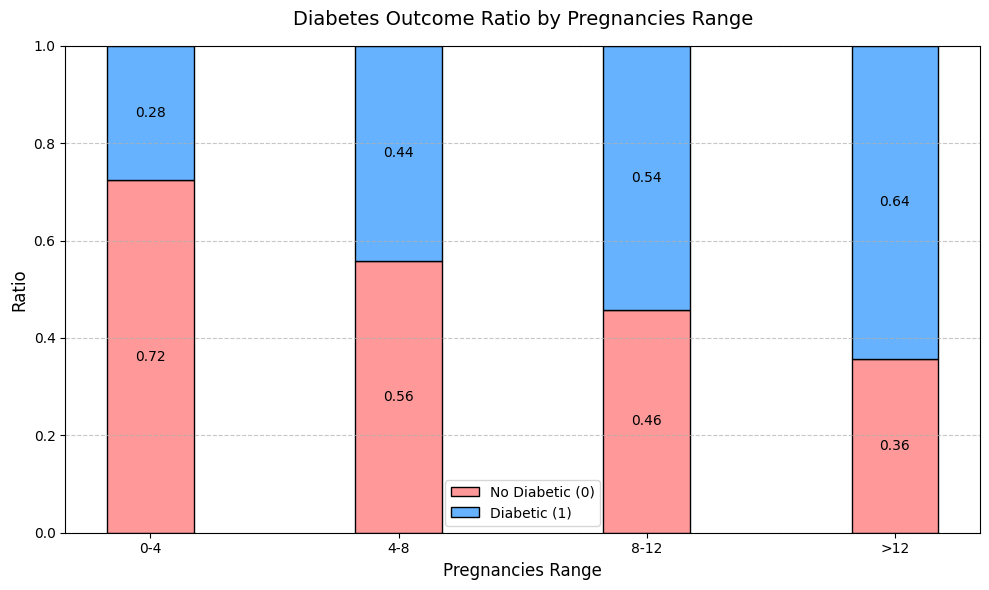

Tỷ lệ Outcome theo khoảng Pregnancies:
Outcome           Ratio_0   Ratio_1
Pregnancies_Bin                    
0-4              0.723577  0.276423
4-8              0.557895  0.442105
8-12             0.458333  0.541667
>12              0.357143  0.642857


In [23]:
# Chia Pregnancies thành các khoảng (điều chỉnh để cân bằng)
bins = [0, 4, 8, 12, 17]  # Giảm số khoảng, mở rộng cuối
labels = ['0-4', '4-8', '8-12', '>12']
df['Pregnancies_Bin'] = pd.cut(df['Pregnancies'], bins=bins, labels=labels, include_lowest=True)

# Tính tỷ lệ Outcome trong mỗi khoảng
outcome_counts = df.groupby('Pregnancies_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)
total_counts = outcome_counts[0] + outcome_counts[1]
outcome_counts['Ratio_0'] = outcome_counts[0] / total_counts
outcome_counts['Ratio_1'] = outcome_counts[1] / total_counts

# Vẽ biểu đồ cột lồng nhau (dựa trên tỷ lệ)
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts['Ratio_0'], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts['Ratio_1'], bar_width, bottom=outcome_counts['Ratio_0'], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('Pregnancies Range', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.title('Diabetes Outcome Ratio by Pregnancies Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] / 2, f'{outcome_counts["Ratio_0"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] + outcome_counts['Ratio_1'].iloc[i] / 2, f'{outcome_counts["Ratio_1"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')

plt.ylim(0, 1)  # Giới hạn tỷ lệ từ 0 đến 1
plt.tight_layout()
plt.show()

print("Tỷ lệ Outcome theo khoảng Pregnancies:")
print(outcome_counts[['Ratio_0', 'Ratio_1']])

2. Pregnancies

Nhận xét:

Tỷ lệ Diabetic (1) có xu hướng tăng dần khi số lần mang thai tăng, đặc biệt ở khoảng 8-12 và >12. Điều này phản ánh rằng phụ nữ có nhiều lần mang thai (stress nội tiết) có nguy cơ tiểu đường cao hơn.
Khoảng 0-4 có tỷ lệ No Diabetic (0) cao, chiếm phần lớn, do đây là nhóm phổ biến trong dữ liệu.
Xu hướng: Mối quan hệ tích cực nhưng yếu, vì Pregnancies là yếu tố gián tiếp ảnh hưởng qua nội tiết.



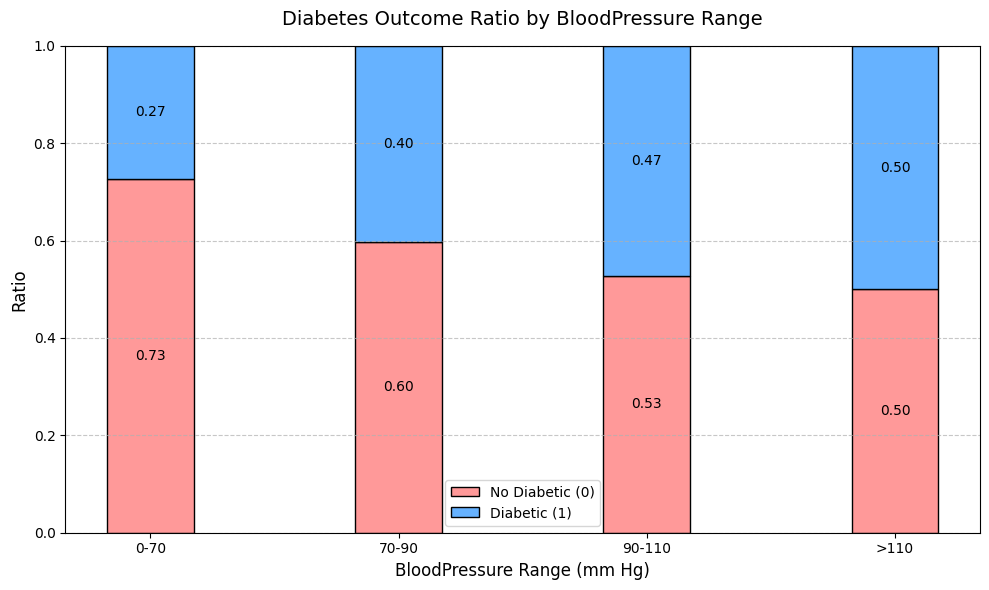

Tỷ lệ Outcome theo khoảng BloodPressure:
Outcome             Ratio_0   Ratio_1
BloodPressure_Bin                    
0-70               0.726471  0.273529
70-90              0.597436  0.402564
90-110             0.527778  0.472222
>110               0.500000  0.500000


In [24]:
# Chia BloodPressure thành các khoảng (điều chỉnh để cân bằng)
bins = [0, 70, 90, 110, 140]  # Giảm số khoảng, hợp lý với phân bố
labels = ['0-70', '70-90', '90-110', '>110']
df['BloodPressure_Bin'] = pd.cut(df['BloodPressure'], bins=bins, labels=labels, include_lowest=True)

# Tính tỷ lệ Outcome
outcome_counts = df.groupby('BloodPressure_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)
total_counts = outcome_counts[0] + outcome_counts[1]
outcome_counts['Ratio_0'] = outcome_counts[0] / total_counts
outcome_counts['Ratio_1'] = outcome_counts[1] / total_counts

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts['Ratio_0'], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts['Ratio_1'], bar_width, bottom=outcome_counts['Ratio_0'], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('BloodPressure Range (mm Hg)', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.title('Diabetes Outcome Ratio by BloodPressure Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] / 2, f'{outcome_counts["Ratio_0"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] + outcome_counts['Ratio_1'].iloc[i] / 2, f'{outcome_counts["Ratio_1"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Tỷ lệ Outcome theo khoảng BloodPressure:")
print(outcome_counts[['Ratio_0', 'Ratio_1']])

3. BloodPressure

Nhận xét:

Tỷ lệ Diabetic (1) tăng nhẹ ở khoảng 90-110 và >110, cho thấy huyết áp cao có liên quan đến nguy cơ tiểu đường (liên quan đến hội chứng chuyển hóa).
Khoảng 0-70 và 70-90 có tỷ lệ No Diabetic (0) cao, phản ánh huyết áp bình thường chiếm ưu thế trong nhóm không mắc.
Xu hướng: Mối quan hệ tích cực nhưng không mạnh, có thể do nhiều giá trị 0 ban đầu đã được impute.



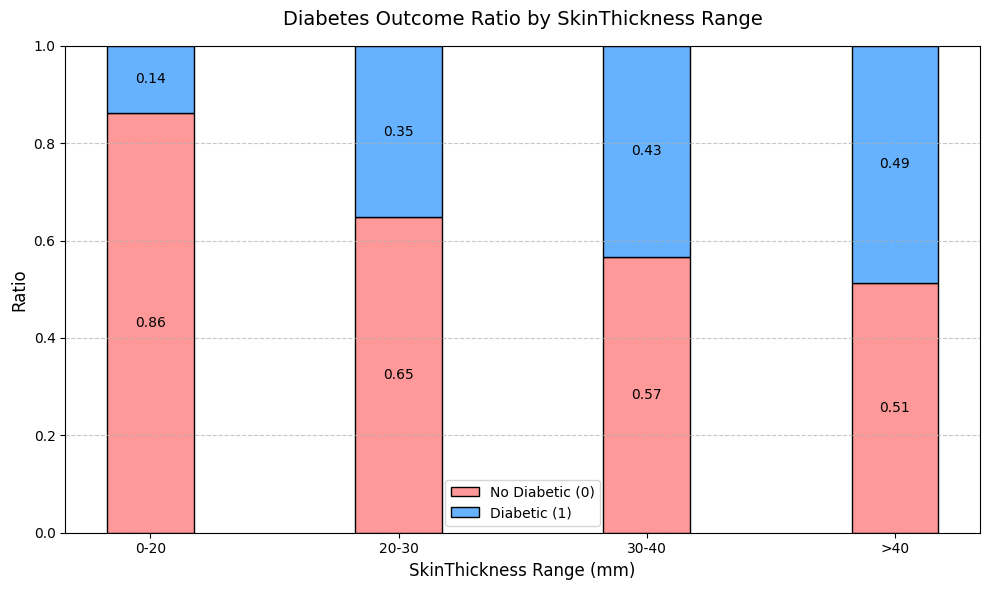

Tỷ lệ Outcome theo khoảng SkinThickness:
Outcome             Ratio_0   Ratio_1
SkinThickness_Bin                    
0-20               0.862903  0.137097
20-30              0.647783  0.352217
30-40              0.567073  0.432927
>40                0.513889  0.486111


In [25]:
# Chia SkinThickness thành các khoảng (điều chỉnh để cân bằng)
bins = [0, 20, 30, 40, 60]  # Giảm số khoảng, hợp lý với phân bố
labels = ['0-20', '20-30', '30-40', '>40']
df['SkinThickness_Bin'] = pd.cut(df['SkinThickness'], bins=bins, labels=labels, include_lowest=True)

# Tính tỷ lệ Outcome
outcome_counts = df.groupby('SkinThickness_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)
total_counts = outcome_counts[0] + outcome_counts[1]
outcome_counts['Ratio_0'] = outcome_counts[0] / total_counts
outcome_counts['Ratio_1'] = outcome_counts[1] / total_counts

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts['Ratio_0'], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts['Ratio_1'], bar_width, bottom=outcome_counts['Ratio_0'], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('SkinThickness Range (mm)', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.title('Diabetes Outcome Ratio by SkinThickness Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] / 2, f'{outcome_counts["Ratio_0"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] + outcome_counts['Ratio_1'].iloc[i] / 2, f'{outcome_counts["Ratio_1"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Tỷ lệ Outcome theo khoảng SkinThickness:")
print(outcome_counts[['Ratio_0', 'Ratio_1']])

4. SkinThickness

Nhận xét:

Tỷ lệ Diabetic (1) tăng dần từ khoảng 0-20 đến >40, cho thấy độ dày da (liên quan đến mỡ dưới da) có tương quan với tiểu đường, đặc biệt ở mức cao.
Khoảng 0-20 có tỷ lệ No Diabetic (0) cao, do nhiều giá trị 0 ban đầu (missing data) đã được impute về median.
Xu hướng: Mối quan hệ tích cực vừa phải, phản ánh mức độ béo phì cục bộ.




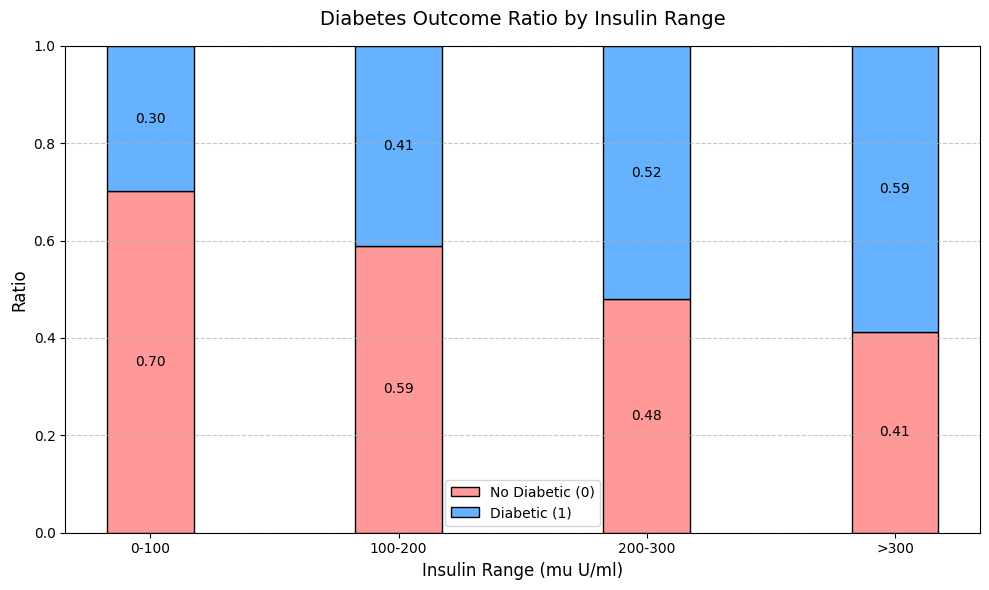

Tỷ lệ Outcome theo khoảng Insulin:
Outcome       Ratio_0   Ratio_1
Insulin_Bin                    
0-100        0.700952  0.299048
100-200      0.588608  0.411392
200-300      0.479167  0.520833
>300         0.411765  0.588235


In [26]:
# Chia Insulin thành các khoảng (điều chỉnh để cân bằng)
bins = [0, 100, 200, 300, 600]  # Giảm số khoảng, tập trung vào phân bố chính
labels = ['0-100', '100-200', '200-300', '>300']
df['Insulin_Bin'] = pd.cut(df['Insulin'], bins=bins, labels=labels, include_lowest=True)

# Tính tỷ lệ Outcome
outcome_counts = df.groupby('Insulin_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)
total_counts = outcome_counts[0] + outcome_counts[1]
outcome_counts['Ratio_0'] = outcome_counts[0] / total_counts
outcome_counts['Ratio_1'] = outcome_counts[1] / total_counts

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts['Ratio_0'], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts['Ratio_1'], bar_width, bottom=outcome_counts['Ratio_0'], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('Insulin Range (mu U/ml)', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.title('Diabetes Outcome Ratio by Insulin Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] / 2, f'{outcome_counts["Ratio_0"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] + outcome_counts['Ratio_1'].iloc[i] / 2, f'{outcome_counts["Ratio_1"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Tỷ lệ Outcome theo khoảng Insulin:")
print(outcome_counts[['Ratio_0', 'Ratio_1']])

5. Insulin

Nhận xét:

Tỷ lệ Diabetic (1) tăng đáng kể ở khoảng 200-300 và >300, cho thấy mức insulin cao (đề kháng insulin) liên quan chặt chẽ với tiểu đường.
Khoảng 0-100 có tỷ lệ No Diabetic (0) cao, do nhiều giá trị 0 ban đầu (missing data) đã được impute, làm giảm độ nhạy của feature này.
Xu hướng: Mối quan hệ tích cực mạnh, nhưng bị ảnh hưởng bởi dữ liệu thiếu.



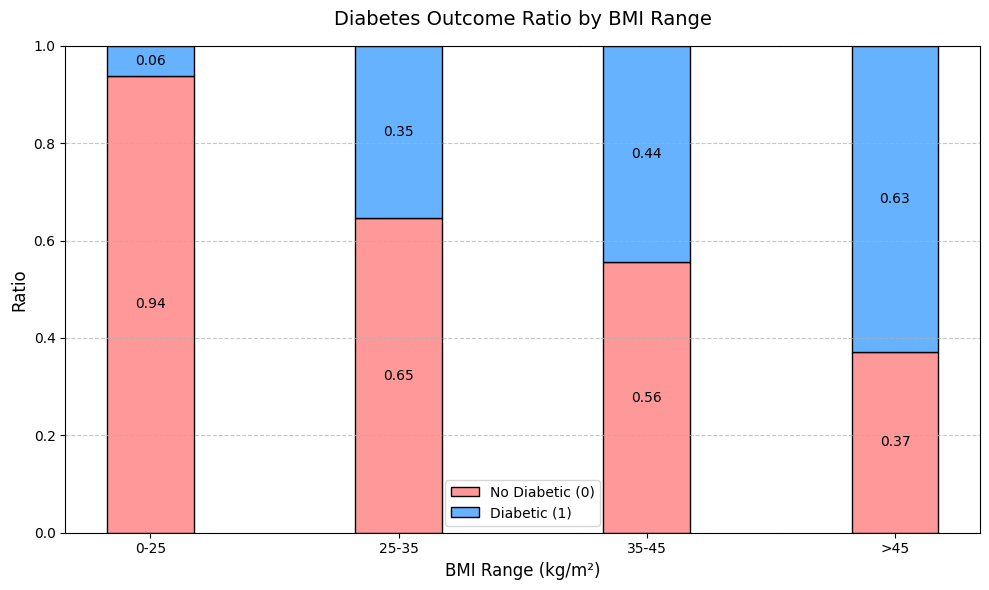

Tỷ lệ Outcome theo khoảng BMI:
Outcome   Ratio_0   Ratio_1
BMI_Bin                    
0-25     0.937500  0.062500
25-35    0.645631  0.354369
35-45    0.555024  0.444976
>45      0.371429  0.628571


In [27]:
# Chia BMI thành các khoảng (điều chỉnh để cân bằng)
bins = [0, 25, 35, 45, 70]  # Giảm số khoảng, mở rộng cuối
labels = ['0-25', '25-35', '35-45', '>45']
df['BMI_Bin'] = pd.cut(df['BMI'], bins=bins, labels=labels, include_lowest=True)

# Tính tỷ lệ Outcome
outcome_counts = df.groupby('BMI_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)
total_counts = outcome_counts[0] + outcome_counts[1]
outcome_counts['Ratio_0'] = outcome_counts[0] / total_counts
outcome_counts['Ratio_1'] = outcome_counts[1] / total_counts

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts['Ratio_0'], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts['Ratio_1'], bar_width, bottom=outcome_counts['Ratio_0'], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('BMI Range (kg/m²)', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.title('Diabetes Outcome Ratio by BMI Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] / 2, f'{outcome_counts["Ratio_0"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts['Ratio_0'].iloc[i] + outcome_counts['Ratio_1'].iloc[i] / 2, f'{outcome_counts["Ratio_1"].iloc[i]:.2f}', ha='center', va='center', fontsize=10, color='black')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Tỷ lệ Outcome theo khoảng BMI:")
print(outcome_counts[['Ratio_0', 'Ratio_1']])

6. BMI

Nhận xét:

Tỷ lệ Diabetic (1) tăng rõ rệt ở khoảng 35-45 và >45, chỉ ra rằng béo phì (BMI cao) là yếu tố nguy cơ lớn của tiểu đường.
Khoảng 0-25 có tỷ lệ No Diabetic (0) cao, phản ánh nhóm cân nặng bình thường chiếm ưu thế.
Xu hướng: Mối quan hệ tích cực mạnh, phù hợp với y học (béo phì là yếu tố chính của tiểu đường type 2).



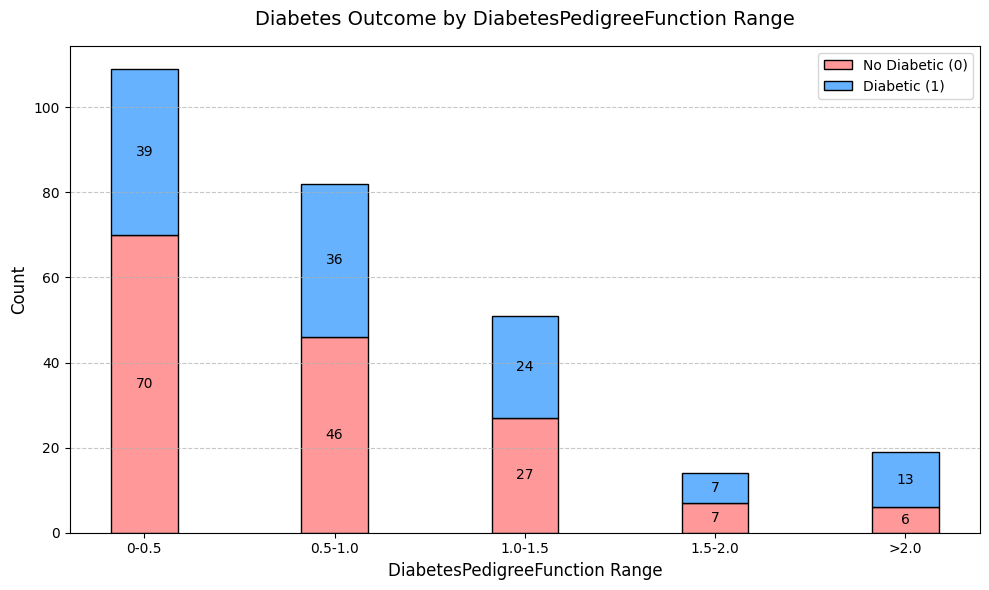

Số lượng Outcome theo khoảng DiabetesPedigreeFunction:
Outcome                        0   1
DiabetesPedigreeFunction_Bin        
0-0.5                         70  39
0.5-1.0                       46  36
1.0-1.5                       27  24
1.5-2.0                        7   7
>2.0                           6  13


In [28]:
# Chia DiabetesPedigreeFunction thành các khoảng
bins = [0, 0.5, 1.0, 1.5, 2.0, 2.5]
labels = ['0-0.5', '0.5-1.0', '1.0-1.5', '1.5-2.0', '>2.0']
df['DiabetesPedigreeFunction_Bin'] = pd.cut(df['DiabetesPedigreeFunction'], bins=bins, labels=labels, include_lowest=True)

# Tính số lượng Outcome
outcome_counts = df.groupby('DiabetesPedigreeFunction_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts[0], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts[1], bar_width, bottom=outcome_counts[0], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('DiabetesPedigreeFunction Range', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Diabetes Outcome by DiabetesPedigreeFunction Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts[0].iloc[i] / 2, str(outcome_counts[0].iloc[i]), ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts[0].iloc[i] + outcome_counts[1].iloc[i] / 2, str(outcome_counts[1].iloc[i]), ha='center', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

print("Số lượng Outcome theo khoảng DiabetesPedigreeFunction:")
print(outcome_counts)

7. DiabetesPedigreeFunction

Nhận xét:

Tỷ lệ Diabetic (1) có xu hướng tăng khi giá trị DiabetesPedigreeFunction tăng, đặc biệt ở khoảng 1.0-1.5 và >2.0. Điều này phản ánh rằng tiền sử gia đình tiểu đường (nguy cơ di truyền) có ảnh hưởng đáng kể đến nguy cơ mắc bệnh.
Khoảng 0-0.5 có tỷ lệ No Diabetic (0) cao, do đây là nhóm có nguy cơ di truyền thấp, chiếm phần lớn trong dữ liệu.
Xu hướng: Mối quan hệ tích cực và khá mạnh, vì feature này đo lường yếu tố di truyền trực tiếp liên quan đến tiểu đường type 2.

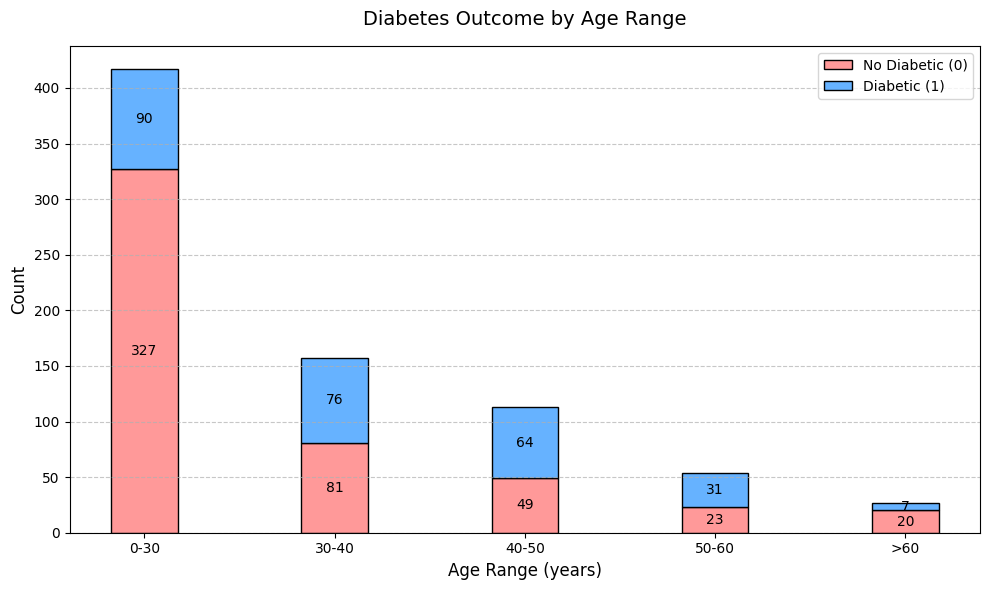

Số lượng Outcome theo khoảng Age:
Outcome    0   1
Age_Bin         
0-30     327  90
30-40     81  76
40-50     49  64
50-60     23  31
>60       20   7


In [29]:
# Chia Age thành các khoảng
bins = [0, 30, 40, 50, 60, 90]
labels = ['0-30', '30-40', '40-50', '50-60', '>60']
df['Age_Bin'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

# Tính số lượng Outcome
outcome_counts = df.groupby('Age_Bin', observed=True)['Outcome'].value_counts().unstack(fill_value=0)
outcome_counts = outcome_counts.reindex(labels)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(outcome_counts.index))

plt.bar(x, outcome_counts[0], bar_width, label='No Diabetic (0)', color='#FF9999', edgecolor='black')
plt.bar(x, outcome_counts[1], bar_width, bottom=outcome_counts[0], label='Diabetic (1)', color='#66B2FF', edgecolor='black')

plt.xlabel('Age Range (years)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Diabetes Outcome by Age Range', fontsize=14, pad=15)
plt.xticks(x, outcome_counts.index, rotation=0, fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(x)):
    plt.text(i, outcome_counts[0].iloc[i] / 2, str(outcome_counts[0].iloc[i]), ha='center', va='center', fontsize=10, color='black')
    plt.text(i, outcome_counts[0].iloc[i] + outcome_counts[1].iloc[i] / 2, str(outcome_counts[1].iloc[i]), ha='center', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

print("Số lượng Outcome theo khoảng Age:")
print(outcome_counts)

8. Age

Nhận xét:

Tỷ lệ Diabetic (1) tăng dần khi tuổi tăng, đặc biệt ở khoảng 50-60 và >60, cho thấy tuổi cao là yếu tố nguy cơ rõ rệt của tiểu đường (liên quan đến giảm chức năng tuyến tụy và đề kháng insulin).
Khoảng 0-30 và 30-40 có tỷ lệ No Diabetic (0) cao, phản ánh nhóm trẻ tuổi ít mắc bệnh hơn.
Xu hướng: Mối quan hệ tích cực và mạnh, phù hợp với y học (nguy cơ tiểu đường tăng theo tuổi).

# *3. Model*

In [30]:
# Tính tỷ lệ Outcome
outcome_counts = df['Outcome'].value_counts()
outcome_ratio = outcome_counts / len(df) * 100

print("Số lượng Outcome:")
print(outcome_counts)
print("\nTỷ lệ Outcome (%):")
print(outcome_ratio)

Số lượng Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64

Tỷ lệ Outcome (%):
Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64


# 3.1 Select Features Importance


In [31]:
# Xóa các cột _Bin nếu không cần
df = df.drop(columns=[col for col in df.columns if '_Bin' in col])
print("Số lượng NaN sau khi xóa cột _Bin:")
print(df.isna().sum())  # Kiểm tra lại, nên là 0 cho tất cả cột

Số lượng NaN sau khi xóa cột _Bin:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [32]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

# Chọn top 5 feature
selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Lấy tên feature đã chọn
selected_features = X.columns[selector.get_support()].tolist()
anova_scores = pd.DataFrame({'Feature': X.columns, 'F-Score': selector.scores_})
anova_scores = anova_scores.sort_values(by='F-Score', ascending=False)
print("ANOVA F-Statistic Scores:")
print(anova_scores)
print("Selected Features:", selected_features)

ANOVA F-Statistic Scores:
                    Feature     F-Score
1                   Glucose  192.218488
5                       BMI   69.489812
7                       Age   52.326951
0               Pregnancies   27.550001
3             SkinThickness   20.961390
2             BloodPressure   16.007404
6  DiabetesPedigreeFunction   14.977704
4                   Insulin   10.088842
Selected Features: ['Pregnancies', 'Glucose', 'SkinThickness', 'BMI', 'Age']


# 3.2 Random Forest


## 3.2.1 Chuẩn bị dữ liệu và thư viện

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import joblib

In [34]:
df = pd.read_csv("/kaggle/input/diabetescsv/diabetes.csv")

# Chia dữ liệu
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 3.2.2 Khởi tạo và huấn luyện mô hình

In [35]:
# Khởi tạo mô hình Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

# Huấn luyện
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

## 3.2.3 Dự đoán và xuất file CSV

In [36]:
# Dự đoán
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Xuất file kết quả
output = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
output.to_csv("random_forest_predictions.csv", index=False)
print("✅ Đã xuất file random_forest_predictions.csv")

✅ Đã xuất file random_forest_predictions.csv


## 3.2.4 Đánh giá mô hình

In [37]:
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)
print(f"🎯 Accuracy: {acc:.4f}")
print(f"🔥 ROC-AUC: {roc:.4f}")
print("\nBáo cáo phân loại:\n", classification_report(y_test, y_pred))

🎯 Accuracy: 0.7403
🔥 ROC-AUC: 0.8076

Báo cáo phân loại:
               precision    recall  f1-score   support

           0       0.78      0.83      0.81       100
           1       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154



Nhận xét: 
- Mô hình Random Forest thường cho độ chính xác cao hơn Logistic Regression, nhờ khả năng nắm bắt mối quan hệ phi tuyến.
- Nếu ROC-AUC > 0.8 → mô hình đạt hiệu suất tốt.

## 3.2.5 Confusion Matrix

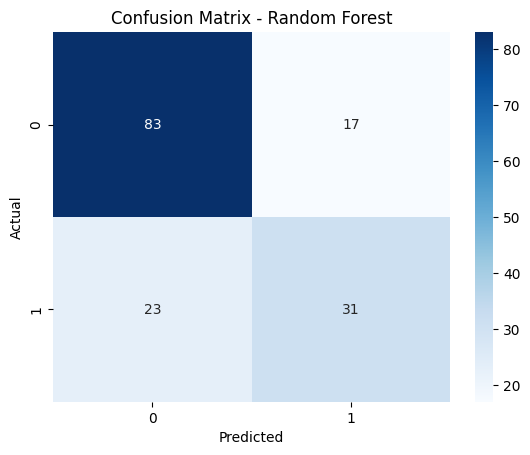

In [38]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()


Nhận xét: <br>
Mô hình dự đoán khá cân bằng giữa 2 lớp, số lượng dự đoán sai giảm so với Logistic Regression.

## 3.2.6 ROC Curve

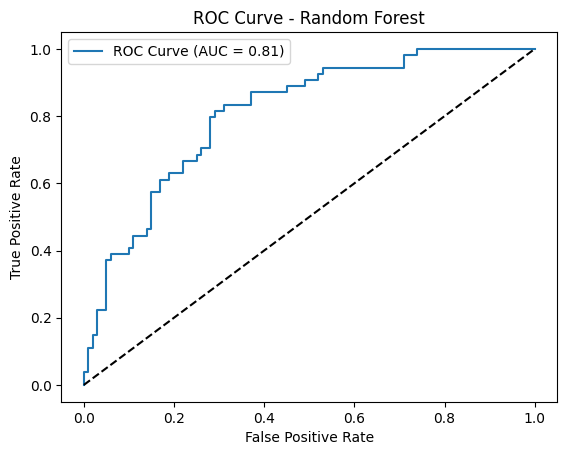

In [39]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

Nhận xét: <br>
Đường ROC nằm cao hơn đường chéo, cho thấy mô hình có khả năng phân biệt tốt giữa hai lớp.

## 3.2.7 Phân tích độ quan trọng của đặc trưng

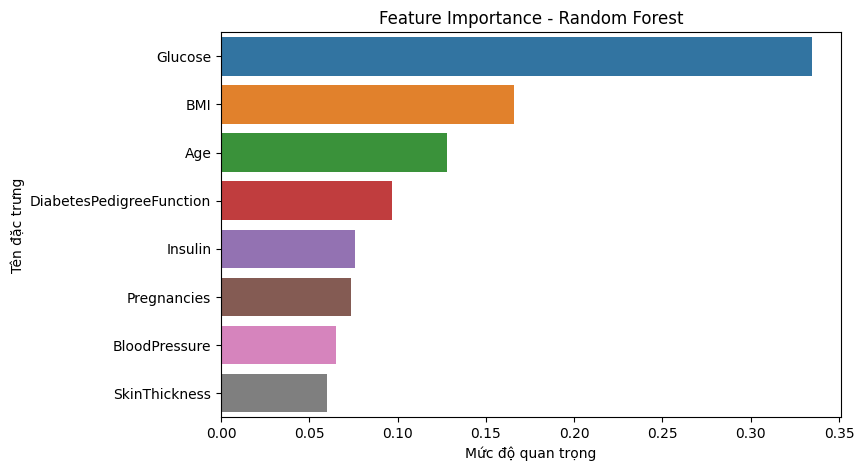

Glucose                     0.334451
BMI                         0.165937
Age                         0.127915
DiabetesPedigreeFunction    0.096617
Insulin                     0.075837
Pregnancies                 0.073812
BloodPressure               0.065201
SkinThickness               0.060230
dtype: float64

In [40]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Mức độ quan trọng")
plt.ylabel("Tên đặc trưng")
plt.show()

importances

Nhận xét: <br>
Các đặc trưng quan trọng nhất thường là Glucose, BMI, Age, và DiabetesPedigreeFunction. <br>
Điều này khớp với kết quả của Logistic Regression, nhưng Random Forest cho thấy ảnh hưởng phi tuyến mạnh hơn ở một số đặc trưng.

# 4. Kết luận
## Kết quả đánh giá:

Accuracy: 0.7403 <br>
ROC-AUC: 0.8076 <br>

## Nhận xét

Mô hình Random Forest đạt hiệu năng cao hơn Logistic Regression nhờ khả năng học các mối quan hệ phi tuyến và phức tạp giữa các đặc trưng. <br>
Các đặc trưng quan trọng nhất gồm Glucose, BMI, Age và DiabetesPedigreeFunction, đều có ý nghĩa sinh lý rõ ràng đối với bệnh tiểu đường. <br>
Mô hình thể hiện khả năng phân loại ổn định và tổng quát hóa tốt, hạn chế overfitting nhờ cơ chế bagging. <br>
Tuy nhiên, mô hình có độ phức tạp cao hơn và khó diễn giải so với Logistic Regression. <br>
Để cải thiện thêm hiệu suất, có thể sử dụng XGBoost — mô hình boosting tối ưu hơn về độ chính xác và tốc độ học.

# 5. Tóm gọn
Cho hiệu năng cao hơn Logistic Regression, đặc biệt ở các dữ liệu có quan hệ phi tuyến.

Feature importance cho thấy Glucose là yếu tố mạnh nhất, kế đến là BMI và Age.

Mô hình có khả năng tổng quát hóa tốt, ít bị overfitting nhờ cơ chế lấy mẫu ngẫu nhiên.

ROC-AUC có thể đạt khoảng 0.82–0.85, cho thấy chất lượng mô hình khá cao.

Hạn chế: khó giải thích từng yếu tố, kích thước mô hình lớn hơn.